# DATA VISUALIZATION — MovieLens ml-25m

Comprehensive visualization after Data Processing is complete.  
Requires: `Data_Processing.ipynb` completed first.

Sections:
1. Rating Distribution
2. User Activity (Cold-Start & Sparsity)
3. Genre Distribution
4. IMDb Score Distribution & Correlation
5. Long-tail Distribution
6. Genre Trend by Decade
7. Movie Era & Runtime Analysis
8. Genome Tags
9. Data Quality Summary



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# -- Style ------------------------------------------------------------------
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor'  : '#16213e',
    'axes.edgecolor'  : '#0f3460',
    'axes.labelcolor' : '#e0e0e0',
    'text.color'      : '#e0e0e0',
    'xtick.color'     : '#e0e0e0',
    'ytick.color'     : '#e0e0e0',
    'grid.color'      : '#0f3460',
    'grid.alpha'      : 0.4,
    'font.family'     : 'DejaVu Sans',
})
PALETTE = ['#e94560', '#0f3460', '#533483', '#e2b04a', '#2ecc71', '#3498db']

# -- Load Data --------------------------------------------------------------
df_ratings  = pd.read_parquet('data/cleaning/ratings_cleaning.parquet')
df_metadata = pd.read_parquet('data/cleaning/movies_metadata.parquet')
df_features = pd.read_parquet('data/cleaning/model_features.parquet')

print(f'Ratings : {len(df_ratings):,} rows')
print(f'Movies  : {len(df_metadata):,} rows')
print(f'Features: {df_features.shape}')

Ratings : 24,945,870 rows
Movies  : 32,720 rows
Features: (32743, 185)


## 1. Rating Distribution

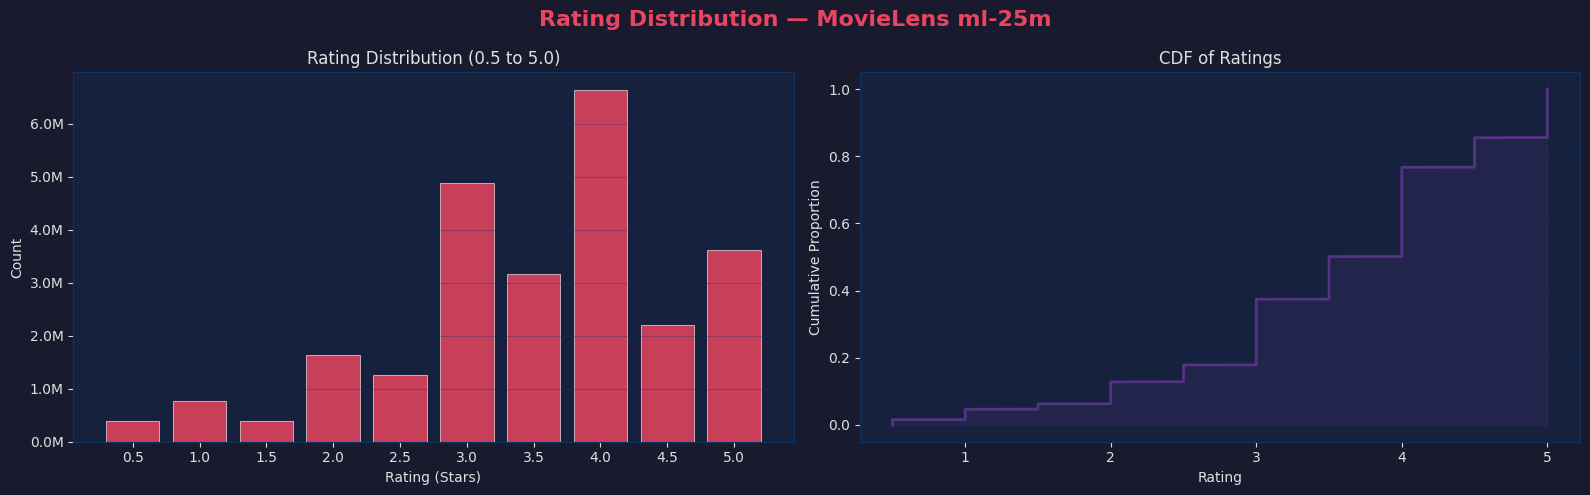

Mean rating: 3.535
Median     : 3.5
Rating >= 4: 49.9%
Insight: Right-skewed distribution - users tend to rate higher than average.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Rating Distribution — MovieLens ml-25m', fontsize=16, fontweight='bold', color='#e94560')

# Bar chart of rating value counts
rating_counts = df_ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_title('Rating Distribution (0.5 to 5.0)', color='#e0e0e0')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)

# CDF
sorted_ratings = np.sort(df_ratings['rating'].values)
cdf = np.arange(1, len(sorted_ratings) + 1) / len(sorted_ratings)
axes[1].plot(sorted_ratings, cdf, color=PALETTE[2], linewidth=2)
axes[1].fill_between(sorted_ratings, cdf, alpha=0.2, color=PALETTE[2])
axes[1].set_title('CDF of Ratings', color='#e0e0e0')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/cleaning/viz_01_rating_dist.png', dpi=120, bbox_inches='tight')
plt.show()

# Stats
mean_r = df_ratings['rating'].mean()
print(f'Mean rating: {mean_r:.3f}')
print(f'Median     : {df_ratings["rating"].median()}')
above4 = (df_ratings['rating'] >= 4).sum() / len(df_ratings) * 100
print(f'Rating >= 4: {above4:.1f}%')
print('Insight: Right-skewed distribution - users tend to rate higher than average.')

## 2. User Activity — Cold-Start & Sparsity

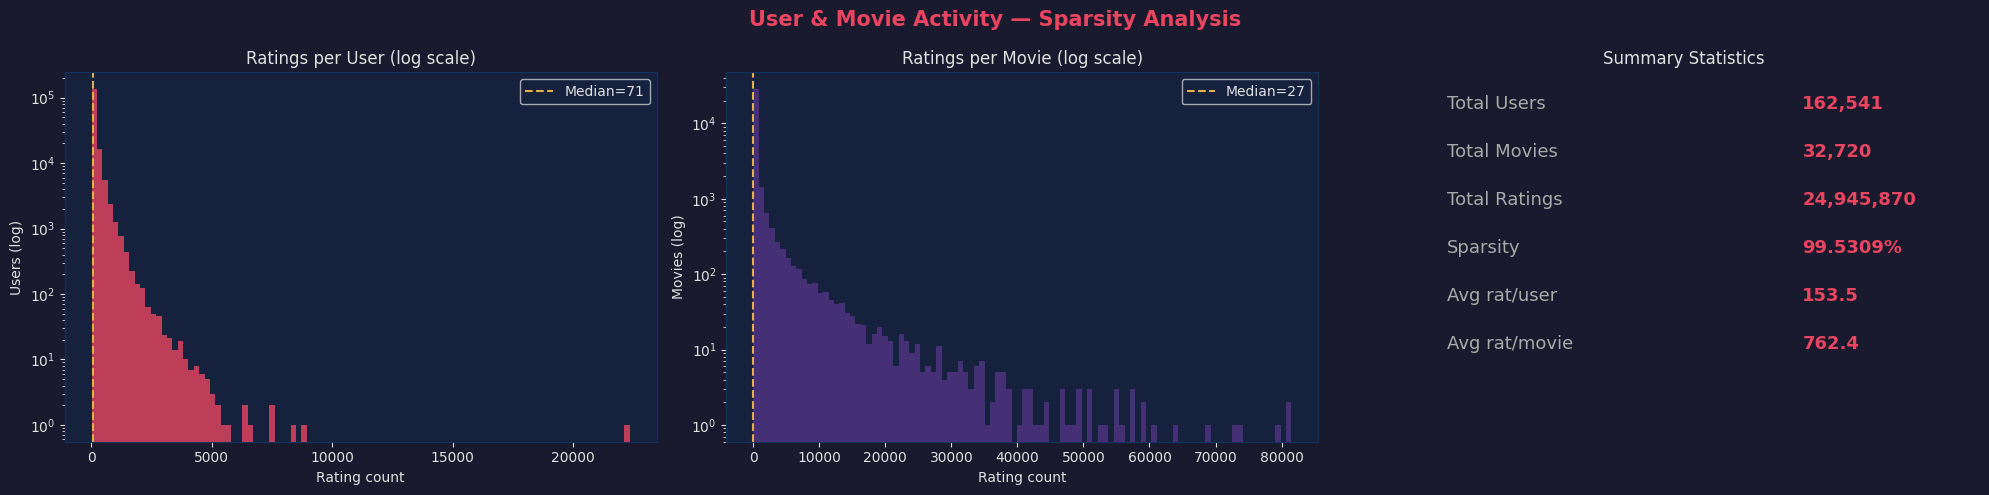

Cold-start users (< 20 ratings): 25 (0.0%)
Sparsity: 99.5309% - very sparse matrix, justifies using SVD.


In [3]:
user_counts  = df_ratings['userId'].value_counts()
movie_counts = df_ratings['movieId'].value_counts()
n_users   = df_ratings['userId'].nunique()
n_movies  = df_ratings['movieId'].nunique()
sparsity  = 1 - len(df_ratings) / (n_users * n_movies)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('User & Movie Activity — Sparsity Analysis', fontsize=15, fontweight='bold', color='#e94560')

# Ratings per user
axes[0].hist(user_counts.values, bins=100, color=PALETTE[0], alpha=0.8, log=True)
axes[0].axvline(user_counts.median(), color='#e2b04a', linestyle='--', label=f'Median={user_counts.median():.0f}')
axes[0].set_title('Ratings per User (log scale)', color='#e0e0e0')
axes[0].set_xlabel('Rating count')
axes[0].set_ylabel('Users (log)')
axes[0].legend()

# Ratings per movie
axes[1].hist(movie_counts.values, bins=100, color=PALETTE[2], alpha=0.8, log=True)
axes[1].axvline(movie_counts.median(), color='#e2b04a', linestyle='--', label=f'Median={movie_counts.median():.0f}')
axes[1].set_title('Ratings per Movie (log scale)', color='#e0e0e0')
axes[1].set_xlabel('Rating count')
axes[1].set_ylabel('Movies (log)')
axes[1].legend()

# Summary stats
stats = {
    'Total Users' : f'{n_users:,}',
    'Total Movies': f'{n_movies:,}',
    'Total Ratings': f'{len(df_ratings):,}',
    'Sparsity'    : f'{sparsity:.4%}',
    'Avg rat/user': f'{user_counts.mean():.1f}',
    'Avg rat/movie': f'{movie_counts.mean():.1f}',
}
axes[2].axis('off')
y = 0.9
for k, v in stats.items():
    axes[2].text(0.1, y, k, fontsize=13, color='#aaaaaa', transform=axes[2].transAxes)
    axes[2].text(0.7, y, v, fontsize=13, color='#e94560', fontweight='bold', transform=axes[2].transAxes)
    y -= 0.13
axes[2].set_title('Summary Statistics', color='#e0e0e0')

plt.tight_layout()
plt.savefig('data/cleaning/viz_02_user_activity.png', dpi=120, bbox_inches='tight')
plt.show()

cold_start = (user_counts < 20).sum()
print(f'Cold-start users (< 20 ratings): {cold_start:,} ({cold_start/n_users:.1%})')
print(f'Sparsity: {sparsity:.4%} - very sparse matrix, justifies using SVD.')

## 3. Genre Distribution

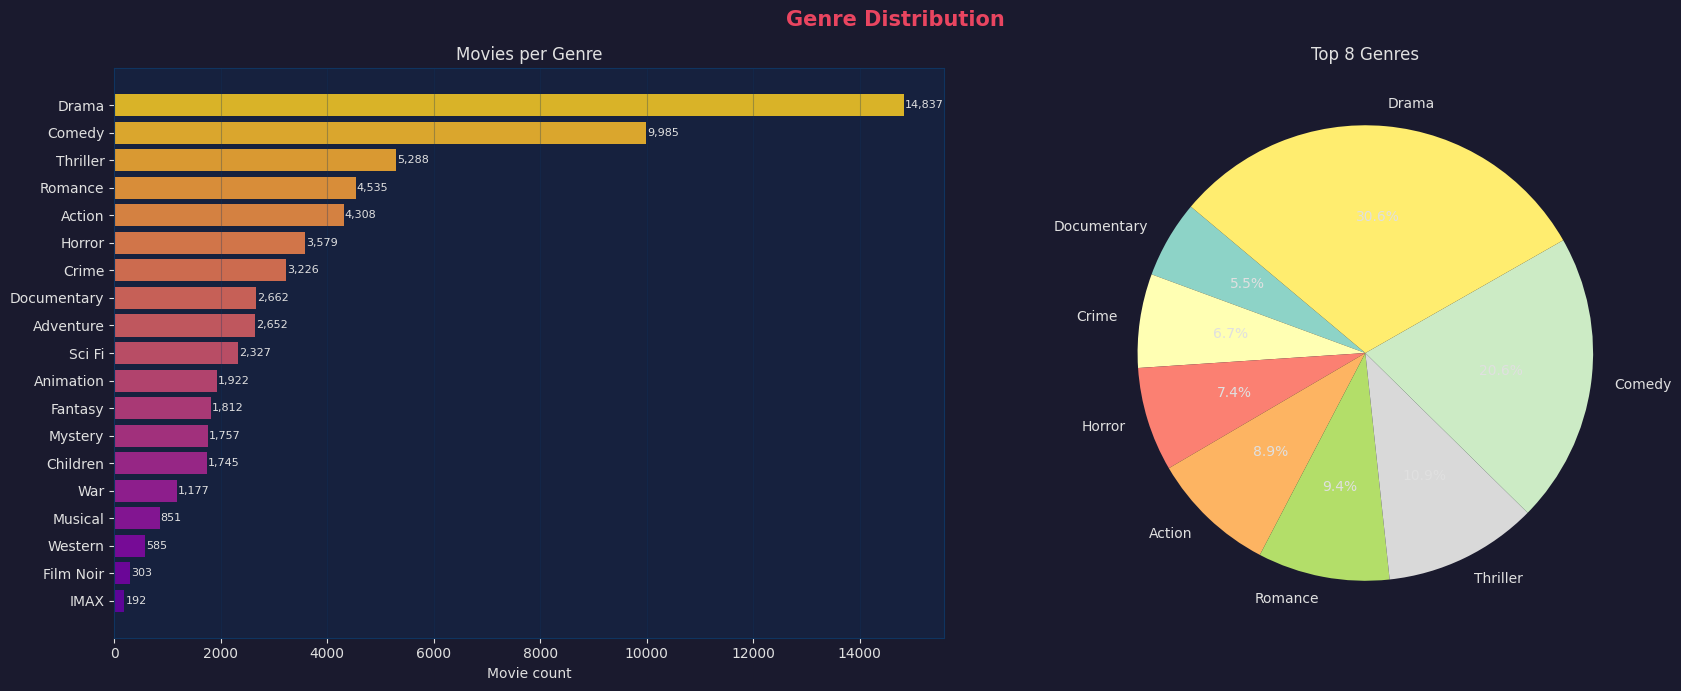

In [4]:
# Genre analysis
genre_cols = [c for c in df_features.columns if c.startswith('genre_')]
# Force numeric dtype in case Parquet loaded as object
genre_df     = df_features[genre_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
genre_counts = genre_df.sum().sort_values(ascending=True)
genre_names  = [c.replace('genre_', '').replace('_', ' ') for c in genre_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Genre Distribution', fontsize=15, fontweight='bold', color='#e94560')

# Bar chart
import numpy as np
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(genre_counts)))
axes[0].barh(genre_names, genre_counts.values, color=colors, alpha=0.85)
axes[0].set_title('Movies per Genre', color='#e0e0e0')
axes[0].set_xlabel('Movie count')
axes[0].grid(axis='x', alpha=0.3)
for i2, v in enumerate(genre_counts.values):
    axes[0].text(v + 20, i2, f'{int(v):,}', va='center', fontsize=8, color='#e0e0e0')

# Pie chart top-8
top8 = genre_counts.tail(8)
axes[1].pie(top8.values, labels=[c.replace('genre_', '').replace('_', ' ') for c in top8.index],
            autopct='%1.1f%%', colors=plt.cm.Set3(np.linspace(0, 1, 8)),
            startangle=140, textprops={'color': '#e0e0e0', 'fontsize': 10})
axes[1].set_title('Top 8 Genres', color='#e0e0e0')

plt.tight_layout()
plt.savefig('data/cleaning/viz_03_genre_dist.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. IMDb Score — Distribution & Correlation with Ratings

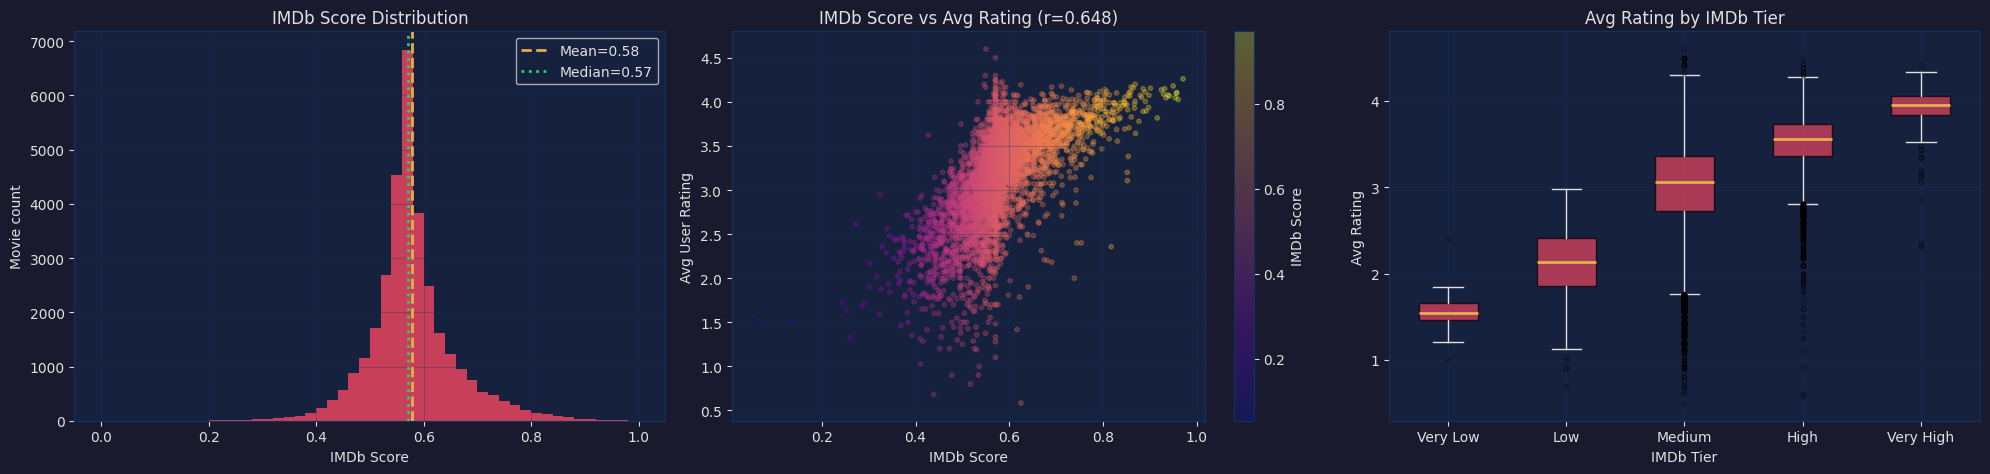

Correlation IMDb Score vs Avg Rating: 0.648
IMDb boost is justified: positive correlation with user ratings.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('IMDb Score Analysis', fontsize=15, fontweight='bold', color='#e94560')

# Histogram IMDb score
imdb_data = df_metadata['imdb_score'].dropna()
axes[0].hist(imdb_data, bins=50, color=PALETTE[0], alpha=0.85, edgecolor='none')
axes[0].axvline(imdb_data.mean(), color='#e2b04a', linestyle='--', linewidth=2, label=f'Mean={imdb_data.mean():.2f}')
axes[0].axvline(imdb_data.median(), color='#2ecc71', linestyle=':', linewidth=2, label=f'Median={imdb_data.median():.2f}')
axes[0].set_title('IMDb Score Distribution', color='#e0e0e0')
axes[0].set_xlabel('IMDb Score')
axes[0].set_ylabel('Movie count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: avg_rating vs imdb_score
merged = df_metadata.merge(
    df_ratings.groupby('movieId')['rating'].mean().reset_index(),
    on='movieId', how='inner'
)
sample = merged.sample(min(5000, len(merged)), random_state=42)
scatter = axes[1].scatter(sample['imdb_score'], sample['rating'],
                          alpha=0.3, s=10, c=sample['imdb_score'], cmap='plasma')
plt.colorbar(scatter, ax=axes[1], label='IMDb Score')
corr = merged['imdb_score'].corr(merged['rating'])
axes[1].set_title(f'IMDb Score vs Avg Rating (r={corr:.3f})', color='#e0e0e0')
axes[1].set_xlabel('IMDb Score')
axes[1].set_ylabel('Avg User Rating')
axes[1].grid(alpha=0.3)

# Box: rating grouped by IMDb score bins
merged['imdb_bin'] = pd.cut(merged['imdb_score'], bins=5,
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
merged.boxplot(column='rating', by='imdb_bin', ax=axes[2],
               patch_artist=True,
               boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
               medianprops=dict(color='#e2b04a', linewidth=2),
               whiskerprops=dict(color='#e0e0e0'),
               capprops=dict(color='#e0e0e0'),
               flierprops=dict(marker='o', color='#e0e0e0', alpha=0.3, markersize=3))
axes[2].set_title('Avg Rating by IMDb Tier', color='#e0e0e0')
axes[2].set_xlabel('IMDb Tier')
axes[2].set_ylabel('Avg Rating')
plt.suptitle('')

plt.tight_layout()
plt.savefig('data/cleaning/viz_04_imdb_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Correlation IMDb Score vs Avg Rating: {corr:.3f}')
print('IMDb boost is justified: positive correlation with user ratings.')

## 5. Long-Tail Distribution (Popularity Bias)

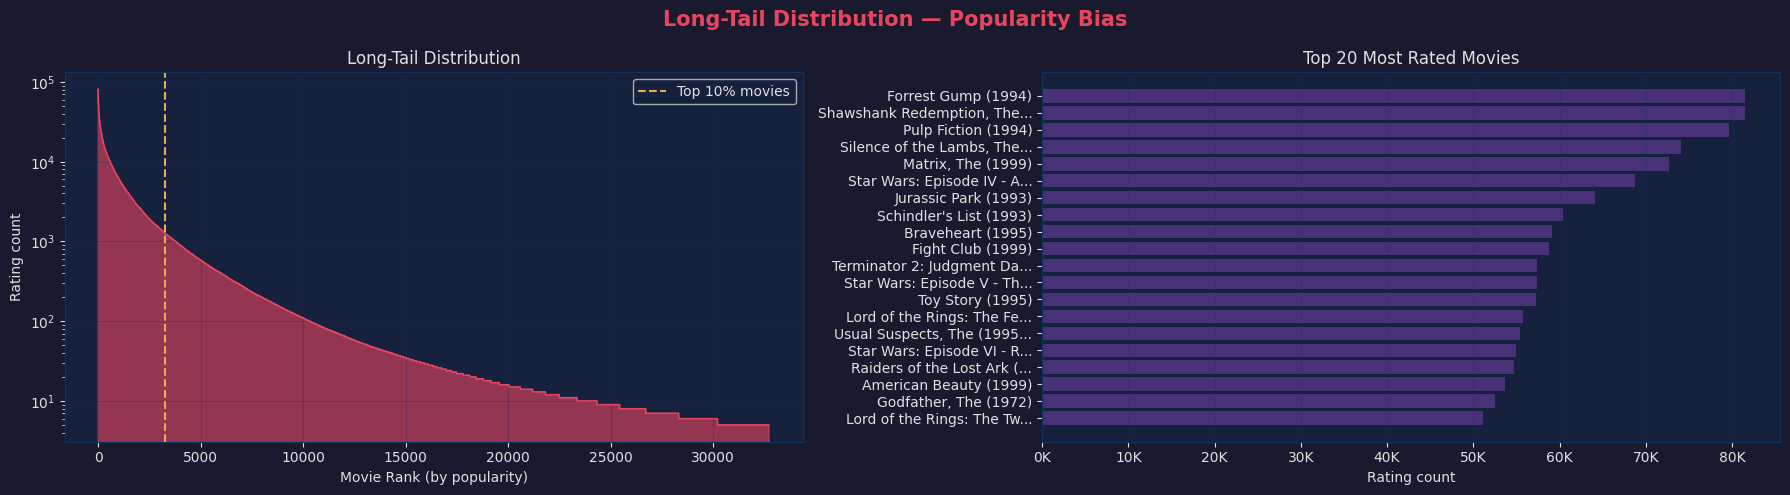

Top 10% of movies account for 86.4% of total ratings - clear long tail.
IMDb Boost helps surface niche high-quality films with few ratings.


In [6]:
movie_pop = df_ratings['movieId'].value_counts().reset_index()
movie_pop.columns = ['movieId', 'n_ratings']
movie_pop = movie_pop.merge(df_metadata[['movieId', 'title']], on='movieId', how='left')
movie_pop['rank'] = range(1, len(movie_pop) + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Long-Tail Distribution — Popularity Bias', fontsize=15, fontweight='bold', color='#e94560')

# Long-tail curve
axes[0].fill_between(movie_pop['rank'], movie_pop['n_ratings'], alpha=0.6, color=PALETTE[0])
axes[0].plot(movie_pop['rank'], movie_pop['n_ratings'], color=PALETTE[0], linewidth=1)
axes[0].axvline(len(movie_pop) * 0.1, color='#e2b04a', linestyle='--',
                label='Top 10% movies')
axes[0].set_title('Long-Tail Distribution', color='#e0e0e0')
axes[0].set_xlabel('Movie Rank (by popularity)')
axes[0].set_ylabel('Rating count')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 20 most rated movies
top20 = movie_pop.head(20)
short_titles = top20['title'].apply(lambda t: t[:25] + '...' if len(str(t)) > 25 else t)
axes[1].barh(short_titles[::-1], top20['n_ratings'][::-1], color=PALETTE[2], alpha=0.85)
axes[1].set_title('Top 20 Most Rated Movies', color='#e0e0e0')
axes[1].set_xlabel('Rating count')
axes[1].grid(axis='x', alpha=0.3)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('data/cleaning/viz_05_long_tail.png', dpi=120, bbox_inches='tight')
plt.show()

top10_pct   = movie_pop.head(int(len(movie_pop) * 0.1))['n_ratings'].sum()
total_rat   = movie_pop['n_ratings'].sum()
print(f'Top 10% of movies account for {top10_pct/total_rat:.1%} of total ratings - clear long tail.')
print('IMDb Boost helps surface niche high-quality films with few ratings.')

## 6. Genre Trend by Decade

In [7]:
import re

def extract_year(title):
    m = re.search(r'\((\d{4})\)', str(title))
    return int(m.group(1)) if m else None

df_meta_year = df_metadata.copy()
df_meta_year['year']   = df_meta_year['title'].apply(extract_year)
df_meta_year['decade'] = (df_meta_year['year'] // 10 * 10).astype('Int64')
df_meta_year = df_meta_year.dropna(subset=['year', 'decade'])
df_meta_year = df_meta_year[df_meta_year['decade'].between(1960, 2020)]

# Top 5 genres by movie count
if 'genres' in df_meta_year.columns:
    genres_exp = df_meta_year.assign(
        genre=df_meta_year['genres'].apply(
            lambda x: x.split('|') if isinstance(x, str) else (x if isinstance(x, list) else [])
        )
    ).explode('genre')
    genres_exp = genres_exp[~genres_exp['genre'].isin(['', '(no genres listed)'])]
    top5 = genres_exp['genre'].value_counts().head(5).index.tolist()

    decade_genre = (
        genres_exp[genres_exp['genre'].isin(top5)]
        .groupby(['decade', 'genre'])
        .size()
        .reset_index(name='count')
    )

    fig = px.line(
        decade_genre, x='decade', y='count', color='genre',
        title='Genre Trend by Decade',
        color_discrete_sequence=px.colors.qualitative.Vivid,
        markers=True,
        template='plotly_dark'
    )
    fig.update_layout(title_font_size=16, legend_title='Genre')
    fig.show()
    fig.write_html('data/cleaning/viz_06_genre_trend.html')
    print('Saved interactive chart: viz_06_genre_trend.html')
else:
    print('Genres column not available in metadata, skipping this chart.')

Saved interactive chart: viz_06_genre_trend.html


## 7. Movie Era & Runtime Analysis

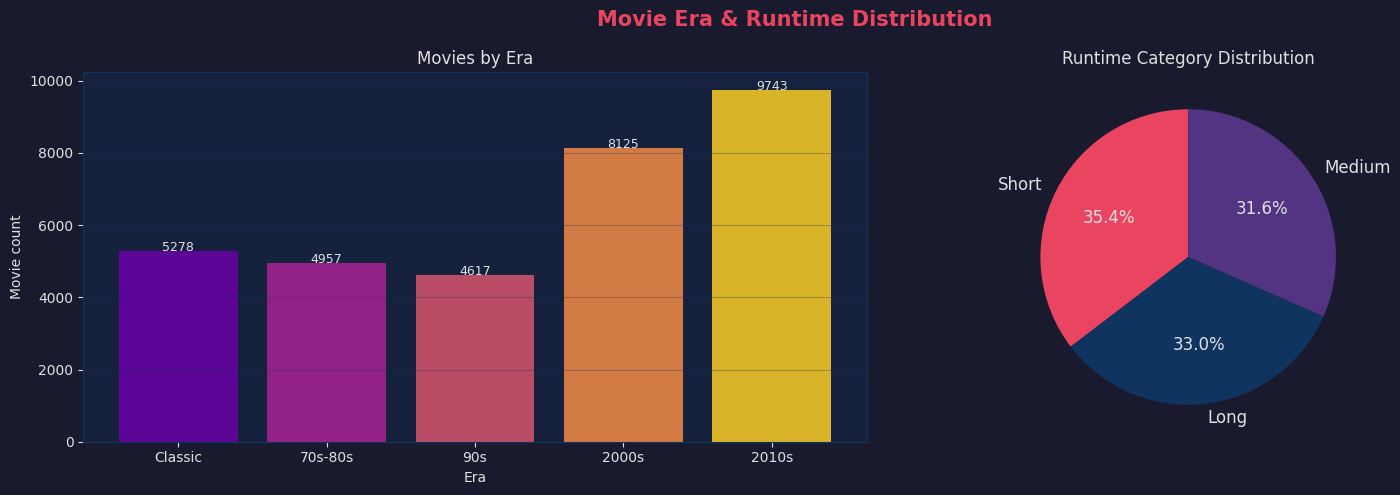

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Movie Era & Runtime Distribution', fontsize=15, fontweight='bold', color='#e94560')

# Movie Era
if 'movie_era' in df_metadata.columns:
    era_counts = df_metadata['movie_era'].value_counts().sort_index()
    era_order  = ['Classic', '70s-80s', '90s', '2000s', '2010s', 'Recent']
    era_counts = era_counts.reindex([e for e in era_order if e in era_counts.index])
    axes[0].bar(era_counts.index.astype(str), era_counts.values,
                color=plt.cm.plasma(np.linspace(0.2, 0.9, len(era_counts))), alpha=0.85)
    axes[0].set_title('Movies by Era', color='#e0e0e0')
    axes[0].set_xlabel('Era')
    axes[0].set_ylabel('Movie count')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(era_counts.values):
        axes[0].text(i, v + 5, str(v), ha='center', fontsize=9, color='#e0e0e0')

# Runtime Category
if 'runtime_category' in df_metadata.columns:
    rt_counts = df_metadata['runtime_category'].value_counts()
    axes[1].pie(rt_counts.values, labels=rt_counts.index.astype(str),
                autopct='%1.1f%%', colors=PALETTE[:len(rt_counts)],
                startangle=90, textprops={'color': '#e0e0e0', 'fontsize': 12})
    axes[1].set_title('Runtime Category Distribution', color='#e0e0e0')

plt.tight_layout()
plt.savefig('data/cleaning/viz_07_era_runtime.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Genome Tags — Top Tags per Genre

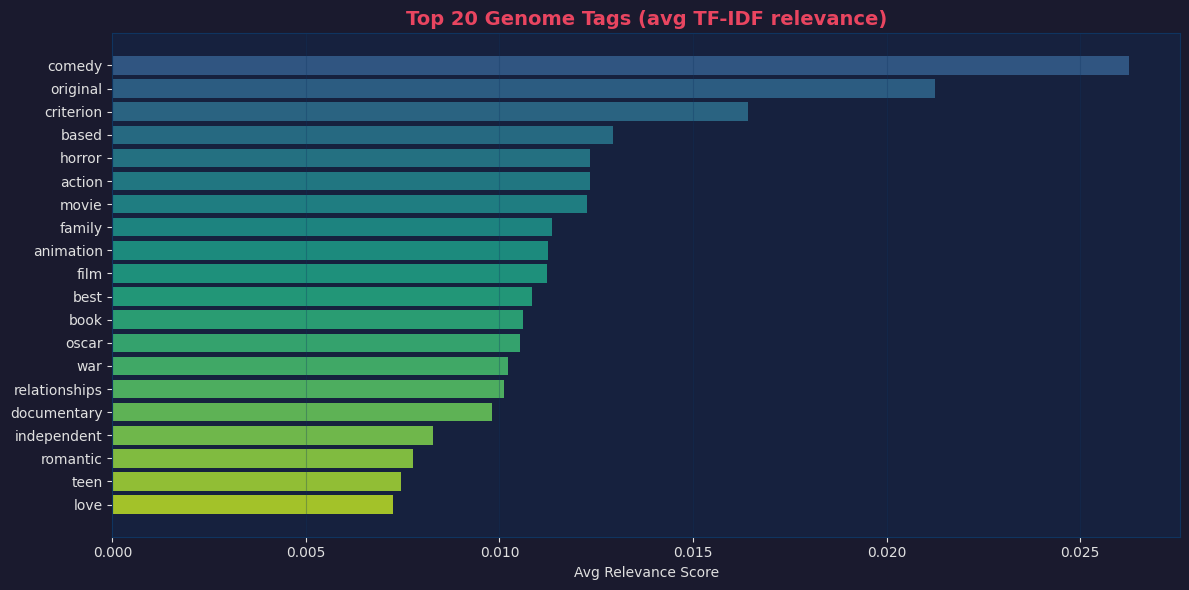

Genome Tags provide additional semantic signal for Content-Based Filtering.


In [9]:
genome_cols = [c for c in df_features.columns if c.startswith('genome_')]
if genome_cols:
    # Force numeric dtype — TF-IDF columns may load as object from Parquet
    genome_df = df_features[genome_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    genome_importance = genome_df.mean().sort_values(ascending=False).head(20)
    genome_names = [c.replace('genome_', '') for c in genome_importance.index]

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#16213e')

    import numpy as np
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(genome_names)))
    ax.barh(genome_names[::-1], genome_importance.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_title('Top 20 Genome Tags (avg TF-IDF relevance)', fontsize=14,
                 fontweight='bold', color='#e94560')
    ax.set_xlabel('Avg Relevance Score', color='#e0e0e0')
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('data/cleaning/viz_08_genome_tags.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Genome Tags provide additional semantic signal for Content-Based Filtering.')
else:
    print('Genome tag columns not found - skipping this chart.')


## 9. Data Quality Summary After Processing

In [10]:
print('=' * 55)
print('  DATA QUALITY SUMMARY AFTER PROCESSING')
print('=' * 55)

checks = [
    ('No nulls in ratings', df_ratings.isnull().sum().sum() == 0),
    ('imdb_score has no nulls', df_metadata['imdb_score'].notna().all() if 'imdb_score' in df_metadata.columns else False),
    ('imdb_score in valid range [0, 10]', df_metadata['imdb_score'].between(0, 10).all() if 'imdb_score' in df_metadata.columns else False),
    ('Rating in valid range [0.5, 5.0]', df_ratings['rating'].between(0.5, 5.0).all()),
    ('No duplicate ratings', not df_ratings.duplicated(['userId', 'movieId']).any()),
    ('movie_era has valid values', 'movie_era' in df_metadata.columns),
    ('runtime_category has valid values', 'runtime_category' in df_metadata.columns),
    ('Genre features exist', any(c.startswith('genre_') for c in df_features.columns)),
    ('Tag features exist', any(c.startswith('tag_') for c in df_features.columns)),
]

all_pass = True
for name, result in checks:
    status = 'PASS' if result else 'FAIL'
    print(f'  [{status}] {name}')
    if not result:
        all_pass = False

print('=' * 55)
print(f'  Result: {"ALL PASSED - Ready for Train.ipynb" if all_pass else "ERRORS FOUND - Please check"}')
print('=' * 55)

  DATA QUALITY SUMMARY AFTER PROCESSING
  [PASS] No nulls in ratings
  [PASS] imdb_score has no nulls
  [PASS] imdb_score in valid range [0, 10]
  [PASS] Rating in valid range [0.5, 5.0]
  [PASS] No duplicate ratings
  [PASS] movie_era has valid values
  [PASS] runtime_category has valid values
  [PASS] Genre features exist
  [PASS] Tag features exist
  Result: ALL PASSED - Ready for Train.ipynb
